In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time
import pandas as pd
import numpy as np

# Selenium Setup
options = webdriver.ChromeOptions()
options.add_argument('--headless')
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

# Landing page URL
driver.get("https://www.doximity.com/residency/")
time.sleep(1)

J3emsYDM3$8P9e*

In [2]:
button = driver.find_element(By.CLASS_NAME, "dropdown-menu-select")
button.click()
time.sleep(1)

lis = driver.find_elements(By.CLASS_NAME, "dropdown-menu-options-item")

link_element = lis[2].find_element(By.TAG_NAME, "a")
link_element.click()
time.sleep(2)

p = driver.find_elements(By.CLASS_NAME, "full-access-banner-signin-prompt")

a = p[0].find_element(By.TAG_NAME, "a")
a.click()
time.sleep(1)

In [3]:
driver.current_url

'https://auth.doximity.com/sessions/login?client_id=2f3e6e7d51c8ac6f0cb870e1304b9c2b210727cbe9c55623bf20f297e3cea11c&redirect_to=https%3A%2F%2Fwww.doximity.com%2Fvue_app%2Fresidency%2Fprograms%3FspecialtyKey%3D15263312-013c-44e9-be20-32fe2528cd93-dermatology%26sortByKey%3Dreputation%26trainingEnvironmentKey%3D%26intendedFellowshipKey%3D'

In [3]:
login_input = driver.find_element(By.ID, 'login')
login_input.send_keys('egorkirsenko1203@gmail.com')

password_input = driver.find_element(By.ID, 'password')
password_input.send_keys('J3emsYDM3$8P9e*')

login_button = driver.find_element(By.ID, "signinbutton")  # или по классу, id
login_button.click()
time.sleep(5)

In [5]:
driver.current_url

'https://www.doximity.com/residency/programs?specialtyKey=15263312-013c-44e9-be20-32fe2528cd93-dermatology&sortByKey=reputation&trainingEnvironmentKey=&intendedFellowshipKey='

In [4]:
while True:
    try:
        but = driver.find_element(By.CLASS_NAME, "residency-show-more-results")
        but.click()
        time.sleep(2)
    except:
        time.sleep(2)
        break

ases = driver.find_elements(By.CLASS_NAME, "residency-navigator-programs-list-item")
len(ases)

142

In [ ]:
#function for getting specialty
def get_specialty(driver):
    spec = driver.find_elements(By.CLASS_NAME, "dropdown-menu-select-title")
    return spec[0].text

#function for getting program info 
def get_program_info(ases, i):
    name = ases[i].text.split('\n')[0]
    print("Program name:", name)
    result["Program name"].append(name)

    text = ases[i].text.split('\n')[-1]
    number = int(text.split(':')[1].strip())
    print("Program size:", number)
    result["Program size"].append(number)

#function for getting program 

In [6]:
result = {"Program name": [], "Program size": [], "Specialty": [], "Coordinator name": [], "Coordinator email": []}

In [ ]:
result = {"Program name": [], "Program size": [], "Specialty": [], "Coordinator name": [], "Coordinator email": []}

for i in range(2):

    spec = driver.find_elements(By.CLASS_NAME, "dropdown-menu-select-title")
    print("Specialty:", spec[0].text)
    result["Specialty"].append(spec[0].text)

    ases = driver.find_elements(By.CLASS_NAME, "residency-navigator-programs-list-item")
    text = ases[i].text.split('\n')[-1]
    number = int(text.split(':')[1].strip())
    print("Program size:", number)
    result["Program size"].append(number)

    name = ases[i].text.split('\n')[0]
    print("Program name:", name)
    result["Program name"].append(name)

    #click ases[0]
    a = ases[i].find_element(By.TAG_NAME, "a")
    driver.execute_script("arguments[0].click();", a)
    time.sleep(1)

    name = driver.find_elements(By.CLASS_NAME, "navigator-program-coordinator-name")
    print("Coordinator name:", name[0].text)
    result["Coordinator name"].append(name[0].text)

    sers = driver.find_elements(By.CLASS_NAME, "navigator-program-coordinator-email")
    txt = sers[0].get_attribute("href")
    start = txt.find(':') + 1
    end = txt.find('?')
    email = txt[start:end]
    print("Coordinator email:", email)
    result["Coordinator email"].append(email)

    driver.back()
    time.sleep(1)
    print("_________________________________________________")

Specialty: Dermatology


NameError: name 'result' is not defined

In [10]:
driver.current_url

'https://www.doximity.com/residency/programs/dce7bd52-d33c-4232-bf79-12b45b025415-wayne-state-university-school-of-medicine-dermatology'

In [11]:
driver.quit()

In [12]:
result

{'Program name': ['University of Pennsylvania Health System',
  'University of California (San Francisco)',
  "Mass General Brigham/Massachusetts General Hospital/Beth Israel Deaconess Medical Center/Brigham and Women's Hosp",
  'NYU Grossman School of Medicine',
  'Yale-New Haven Medical Center',
  'Stanford Health Care-Sponsored Stanford University',
  'University of Texas Southwestern Medical Center',
  'McGaw Medical Center of Northwestern University',
  'Mayo Clinic College of Medicine and Science (Rochester)',
  'Icahn School of Medicine at Mount Sinai',
  'University of Michigan',
  'University of Miami/Jackson Health System',
  'Emory University School of Medicine',
  'Henry Ford Health/Henry Ford Hospital',
  'Mayo Clinic College of Medicine and Science (Scottsdale)',
  'University of Iowa Hospitals and Clinics',
  'Washington University/B-JH/SLCH Consortium',
  'Duke University Hospital',
  'Mayo Clinic College of Medicine and Science (Jacksonville)',
  'University of Souther

In [13]:
#save to xlsx
df = pd.DataFrame(result)
df.to_excel("result.xlsx")
df

ValueError: All arrays must be of the same length

In [9]:
from selenium.webdriver.common.by import By
import time

def get_specialty(driver):
    spec = driver.find_elements(By.CLASS_NAME, "dropdown-menu-select-title")
    specialty = spec[0].text if spec else "N/A"
    print("Specialty:", specialty)
    return specialty

def get_program_info(program_element):
    lines = program_element.text.split('\n')
    name = lines[0] if lines else "N/A"
    size_line = lines[-1] if lines else ""
    try:
        size = int(size_line.split(':')[1].strip())
    except (IndexError, ValueError):
        size = 0
    print("Program name:", name)
    print("Program size:", size)
    return name, size

def open_program_details(program_element, driver):
    link = program_element.find_element(By.TAG_NAME, "a")
    driver.execute_script("arguments[0].click();", link)
    time.sleep(1)

def get_coordinator_info(driver):
    name_elements = driver.find_elements(By.CLASS_NAME, "navigator-program-coordinator-name")
    email_elements = driver.find_elements(By.CLASS_NAME, "navigator-program-coordinator-email")

    name = name_elements[0].text if name_elements else "N/A"
    email = "N/A"
    if email_elements:
        href = email_elements[0].get_attribute("href")
        start = href.find(':') + 1
        end = href.find('?')
        email = href[start:end] if start != -1 and end != -1 else "N/A"

    print("Coordinator name:", name)
    print("Coordinator email:", email)
    return name, email

# основной цикл
ases = driver.find_elements(By.CLASS_NAME, "residency-navigator-programs-list-item")

for i in range(len(ases)):
    specialty = get_specialty(driver)
    result["Specialty"].append(specialty)

    # пересоздаем список на каждой итерации
    ases = driver.find_elements(By.CLASS_NAME, "residency-navigator-programs-list-item")
    program_name, program_size = get_program_info(ases[i])
    result["Program name"].append(program_name)
    result["Program size"].append(program_size)

    open_program_details(ases[i], driver)
    coord_name, coord_email = get_coordinator_info(driver)
    result["Coordinator name"].append(coord_name)
    result["Coordinator email"].append(coord_email)

    driver.back()
    time.sleep(1)
    print("_________________________________________________")


Specialty: Dermatology
Program name: University of Pennsylvania Health System
Program size: 25
Coordinator name: Ms. Barbara Lang
Coordinator email: barbara.lang@pennmedicine.upenn.edu
_________________________________________________
Specialty: Dermatology
Program name: University of California (San Francisco)
Program size: 22
Coordinator name: Ms. Laura Harrison
Coordinator email: laura.harrison@ucsf.edu
_________________________________________________
Specialty: Dermatology
Program name: Mass General Brigham/Massachusetts General Hospital/Beth Israel Deaconess Medical Center/Brigham and Women's Hosp
Program size: 29
Coordinator name: Diane Kovacev
Coordinator email: dkovacev@partners.org
_________________________________________________
Specialty: Dermatology
Program name: NYU Grossman School of Medicine
Program size: 25
Coordinator name: Vikash Oza, MD
Coordinator email: vikash.oza@nyulangone.org
_________________________________________________
Specialty: Dermatology
Program name

In [11]:
df = pd.DataFrame(result)
df

,Program name,Program size,Specialty,Coordinator name,Coordinator email
0,University of Pennsylvania Health System,25,Dermatology,Ms. Barbara Lang,barbara.lang@pennmedicine.upenn.edu
1,University of California (San Francisco),22,Dermatology,Ms. Laura Harrison,laura.harrison@ucsf.edu
2,University of Pennsylvania Health System,25,Dermatology,Ms. Barbara Lang,barbara.lang@pennmedicine.upenn.edu
3,University of California (San Francisco),22,Dermatology,Ms. Laura Harrison,laura.harrison@ucsf.edu
4,Mass General Brigham/Massachusetts General Hos...,29,Dermatology,Diane Kovacev,dkovacev@partners.org
...,...,...,...,...,...
139,Ponce Health Sciences University,9,Dermatology,"Mr. Anthony Feliciano, BA",afeliciano@psm.edu
140,Samaritan Health Services - Corvallis,9,Dermatology,Mrs. Zoia Martushev,zmartushev@frontierdermpartners.com
141,HCA Healthcare LewisGale Hospital-Montgomery/VCOM,6,Dermatology,"Mrs. Donna Underwood, MBA, MS",donna.underwood@hcahealthcare.com
142,St Luke’s Hospital – Anderson Campus,9,Dermatology,Ms. Deanna Kuhn,Deanna.Kuhn@sluhn.org


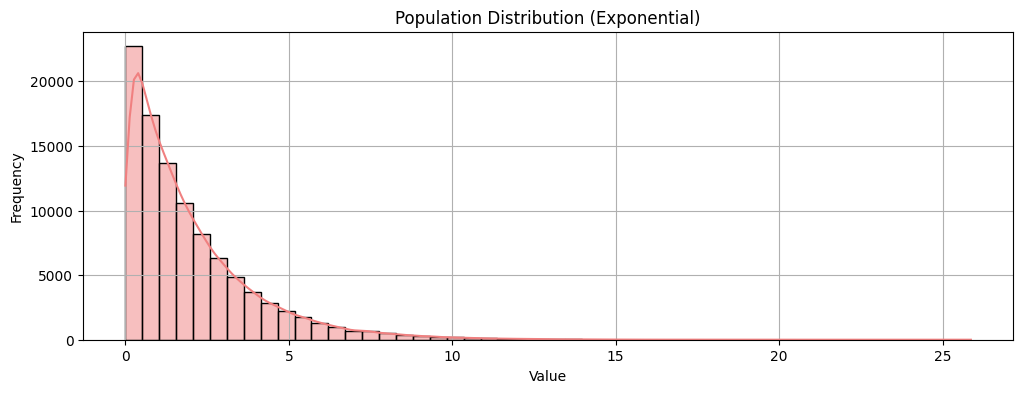

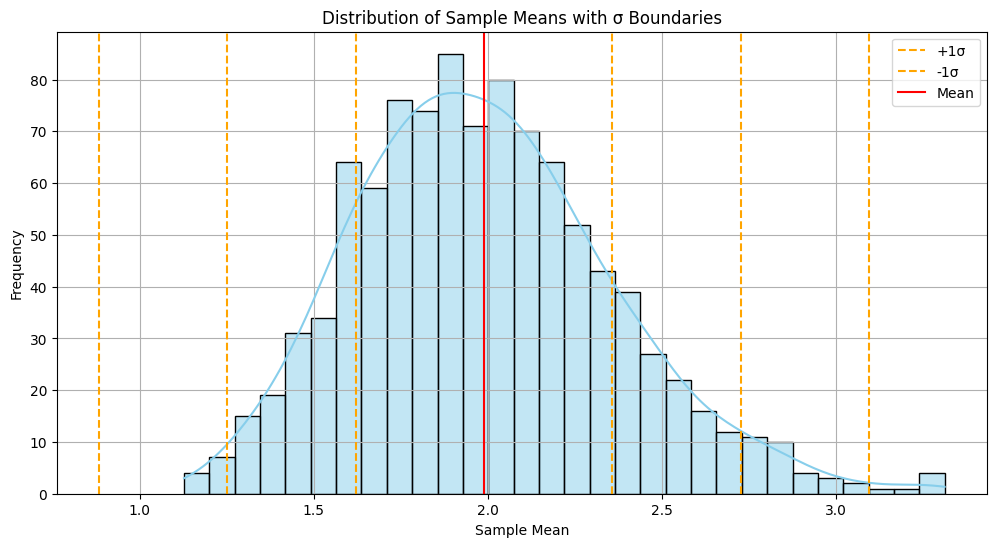

Mean of sample means: 1.9883
Standard deviation of sample means: 0.3683
Percentage within ±1σ: 68.90%
Percentage within ±2σ: 95.60%
Percentage within ±3σ: 99.40%


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate population (exponential distribution)
population_size = 100000
population = np.random.exponential(scale=2, size=population_size)

# Sample parameters
sample_size = 30
num_samples = 1000
sample_means = []

# Generate samples and compute sample means
for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_means.append(np.mean(sample))

# Plot population distribution
plt.figure(figsize=(12, 4))
sns.histplot(population, bins=50, kde=True, color='lightcoral')
plt.title('Population Distribution (Exponential)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Compute mean and standard deviation of sample means
mean_of_means = np.mean(sample_means)
std_of_means = np.std(sample_means)

# Plot distribution of sample means
plt.figure(figsize=(12, 6))
sns.histplot(sample_means, kde=True, bins=30, color='skyblue')

# Add vertical lines for ±1σ, ±2σ, ±3σ
for i in range(1, 4):
    plt.axvline(mean_of_means + i * std_of_means, color='orange', linestyle='--', label=f'+{i}σ' if i == 1 else None)
    plt.axvline(mean_of_means - i * std_of_means, color='orange', linestyle='--', label=f'-{i}σ' if i == 1 else None)

# Add vertical line for mean
plt.axvline(mean_of_means, color='red', linestyle='-', label='Mean')

plt.title('Distribution of Sample Means with σ Boundaries')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Sigma rule checks
within_1_sigma = [m for m in sample_means if abs(m - mean_of_means) <= 1 * std_of_means]
within_2_sigma = [m for m in sample_means if abs(m - mean_of_means) <= 2 * std_of_means]
within_3_sigma = [m for m in sample_means if abs(m - mean_of_means) <= 3 * std_of_means]

print(f"Mean of sample means: {mean_of_means:.4f}")
print(f"Standard deviation of sample means: {std_of_means:.4f}")
print(f"Percentage within ±1σ: {len(within_1_sigma) / num_samples * 100:.2f}%")
print(f"Percentage within ±2σ: {len(within_2_sigma) / num_samples * 100:.2f}%")
print(f"Percentage within ±3σ: {len(within_3_sigma) / num_samples * 100:.2f}%")

